In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd


import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph_hashed import DFGrepInterference, DFGrepWorkflow 

if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None

# App Name
app_name = "deepspeed-dlio-scr-step100" 


condition_fn = None #

if app_name == "cm1":
    # filename = "/p/lustre3/pandey2/logs/cm1/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cm1/APP/node-32/v1/COMPACT/*.pfw.gz"
    cp_dir = "/p/lustre3/pandey2/logs/result_checkpoint"

elif app_name == "cosmoflow":
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cosmoflow/dlio-v100/node-16/v1/COMPACT/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cosmoflow/dlio-v100/node-4/v1/COMPACT/*1*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/result_checkpoint"

elif app_name == "deepspeed-dlio-step100":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-step100/node-16/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/result_checkpoint"

elif app_name == "deepspeed-dlio-scr-step100":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-scr-step100/node-16/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/result_checkpoint"
else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, debug=True,
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=True, 
                                host_pattern=r'lassen(\d+)', time_granularity=0.5e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

[INFO] [12:30:12] Initialized Client with 192 workers and link http://134.9.71.20:8787/status [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:769]


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


[INFO] [12:30:18] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:761]


In [4]:
# reset_dask_cluster()
# filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-step100/node-16/v1/COMPACT/*1*.pfw.gz"

In [4]:
def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))


In [5]:
def cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return '/'.join(path.split('/', 3)[:3])

    if "M" == json_object["ph"] and "FH" == json_object["name"] and "args" in json_object and "name" in json_object["args"]:
        d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=json_object["args"]["name"])
    if "args" in json_object and "M" != json_object["ph"]:
        if "ret" in json_object["args"]:
            d["size"] = int(json_object["args"]["ret"]) 
    return d

load_cols = {'size': "int64[pyarrow]" }
load_cols_metadata = {"FH":{'mount_point':"string[pyarrow]" }}

In [6]:
# def montage_cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
#     d = {}
#     def find_mount_point(path,trie):
#         mount_point = trie.longest_prefix(path)
#         if mount_point:
#             return mount_point.key
#         return '/'.join(path.split('/', 3)[:3])

#     if "M" == json_object["ph"] and "FH" == json_object["name"] and "args" in json_object and "name" in json_object["args"]:
#         d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=json_object["args"]["name"])
#     if "args" in json_object and "M" != json_object["ph"]:
#         if "ret" in json_object["args"]:
#             d["size"] = int(json_object["args"]["ret"]) 
#     return d

# # load_cols_montage = {'filename':"string[pyarrow]",'mount_point':"string[pyarrow]", 'size': "uint64[pyarrow]" }
# load_cols_montage = {'size': "int64[pyarrow]" }
# load_cols_montage_metadata = {"FH":{'mount_point':"string[pyarrow]" }}
# analyzer = DFAnalyzer(filename)
# analyzer.file_hash.head()
# analyzer.host_hash.head()
# analyzer.file_hash.head()


In [7]:
analyzer = DFAnalyzer(filename,load_fn=cols_function, load_cols=load_cols, load_data={"mount_point":trie}, metadata_cols = load_cols_metadata)

[INFO] [12:30:34] Created index for 16 files [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:428]
[INFO] [12:30:34] Total size of all files are <dask.bag.core.Item object at 0x1554ab472f40> bytes [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:430]
[INFO] [12:30:34] test debug [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:433]
[INFO] [12:30:38] Loading 8410 batches out of 16 files and has 137639290 lines overall [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:444]
[INFO] [12:34:56] Loaded events [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:511]
[INFO] [12:34:56] Loaded plots with slope threshold: 45 [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:517]


In [8]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index

In [ ]:
# filter_mp_data = ["/dev/shm","/l/ssd", "/p/lustre3","/var/tmp", "/sys"] 
filter_mp_data = ["/dev/shm"] 
filter_mp_metadata = ["/dev/shm", "/p/lustre3","/l/ssd","/tmp", "/usr/workspace"] 

In [9]:
IFCalculator = DFGrepInterference(analyze_df, app_name=app_name, cp_dir=cp_dir, existing=False)

In [10]:
IFCalculator.ddf_data.groupby("mount_point").count().compute()

,id,name,cat,size,ts,te,dur,trange,hostname
mount_point,,,,,,,,,
/dev/shm,782016,782016,782016,782016,782016,782016,782016,782016,782016
/l/ssd,44225245,44225245,44225245,44225245,44225245,44225245,44225245,44225245,44225245
/p/lustre3,728642,728642,728642,728642,728642,728642,728642,728642,728642
/usr/workspace,20056420,20056420,20056420,20056420,20056420,20056420,20056420,20056420,20056420
/sys,370414,370414,370414,370414,370414,370414,370414,370414,370414
/collab/usr/gapps,63744,63744,63744,63744,63744,63744,63744,63744,63744
/dev,8192,8192,8192,8192,8192,8192,8192,8192,8192
/g/g92,512,512,512,512,512,512,512,512,512
/proc,35456,35456,35456,35456,35456,35456,35456,35456,35456


In [13]:
IFCalculator.ddf_data = IFCalculator.ddf_data[IFCalculator.ddf_data["mount_point"].isin(filter_mp_data)]
IFCalculator.ddf_metadata = IFCalculator.ddf_metadata[IFCalculator.ddf_metadata["mount_point"].isin(filter_mp_metadata)]

In [12]:
# IFCalculator.ddf_metadata.groupby("mount_point").count().compute()

In [14]:
IFCalculator.get_degree()

[INFO] [12:46:18]  Finding degree for data columns started ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:114]


[INFO] [12:46:18]  Degree for data Completed ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:118]
[INFO] [12:46:18]  Degree for metadata Started ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:119]
[INFO] [12:46:18]  Degree for data Completed ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:122]


In [ ]:
# data = IFCalculator.deg_data.compute()
# metadata = IFCalculator.deg_metadata.compute()

In [ ]:
IFCalculator.get_interference()

In [ ]:
IFCalculator.get_interference_metadata()

In [17]:
data

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,deg
0,150158,open,POSIX,69,664888245,664888260,15,664,/dev/shm,corona192,2
1,103753,open,POSIX,69,664888255,664888269,14,664,/dev/shm,corona193,2
2,145412,open,POSIX,69,664888270,664888282,12,664,/dev/shm,corona193,2
3,164889,open,POSIX,69,664888278,664888292,14,664,/dev/shm,corona193,4
4,150161,write,POSIX,1,664888283,664888288,5,664,/dev/shm,corona192,3
...,...,...,...,...,...,...,...,...,...,...,...
6011,461096,write,POSIX,33554432,7917994751,7918049663,54912,7917,/p/lustre3,corona207,99
6012,176965,write,POSIX,33554432,7917994966,7918092590,97624,7917,/p/lustre3,corona193,99
6013,441763,write,POSIX,33554432,7917995105,7918191175,196070,7917,/p/lustre3,corona201,99
6014,71791,write,POSIX,33554432,7917997388,7918050715,53327,7917,/p/lustre3,corona205,98


In [ ]:
# data.deg.max()
# metadata.query('deg > 2000')
# IFCalculator.ddf_metadata.query('ts > 231869329 and te < 231887212').compute()

np.int64(692)

In [40]:
metadata.groupby(['trange','mount_point']).size().reset_index(name="Count").sort_values(by="Count",ascending = False).head(10)

,trange,mount_point,Count
207,52,/usr/WS2,163357
197,50,/usr/WS2,148461
202,51,/usr/WS2,122007
192,49,/usr/WS2,117745
247,67,/usr/WS2,104517
212,53,/usr/WS2,96700
509,469,/usr/WS2,71715
252,68,/usr/WS2,70528
19,4,/collab/usr/gapps,66996
23,4,/usr/WS2,64478


In [25]:
data.groupby("mount_point").count()

,id,name,cat,size,ts,te,dur,trange,hostname,deg
mount_point,,,,,,,,,,
/collab/usr/gapps,8928,8928,8928,8928,8928,8928,8928,8928,8928,8928
/dev,1152,1152,1152,1152,1152,1152,1152,1152,1152,1152
/dev/shm,109638,109638,109638,109638,109638,109638,109638,109638,109638,109638
/g/g92,72,72,72,72,72,72,72,72,72,72
/p/lustre3,26532,26532,26532,26532,26532,26532,26532,26532,26532,26532
/proc,4986,4986,4986,4986,4986,4986,4986,4986,4986,4986
/sys,52020,52020,52020,52020,52020,52020,52020,52020,52020,52020
/usr/WS2,237186,237186,237186,237186,237186,237186,237186,237186,237186,237186
/usr/share,54,54,54,54,54,54,54,54,54,54


In [ ]:
mount_points = ["/dev/shm", "/p/lustre3","/var/tmp", "/sys"] # significant missed /usr/workspace 2.8M usr WS2 237K
mount_points_metadata = ["/dev/shm", "/p/lustre3","/var/tmp", "/sys","/dev","/collab", "/usr/workspace"] #significant missed 2M usr WS2

In [27]:
metadata.groupby("mount_point").count()

,id,name,cat,size,ts,te,dur,trange,hostname,deg
mount_point,,,,,,,,,,
./,36,36,36,0,36,36,36,36,36,36
/collab,10422,10422,10422,0,10422,10422,10422,10422,10422,10422
/collab/usr,10422,10422,10422,0,10422,10422,10422,10422,10422,10422
/collab/usr/gapps,199854,199854,199854,17514,199854,199854,199854,199854,199854,199854
/dev,2862,2862,2862,558,2862,2862,2862,2862,2862,2862
/dev/shm,326779,326779,326779,54385,326779,326779,326779,326779,326779,326779
/etc/crypto-policies,144,144,144,0,144,144,144,144,144,144
/etc/libfabric.conf,36,36,36,0,36,36,36,36,36,36
/etc/libibverbs.d,756,756,756,0,756,756,756,756,756,756


In [ ]:
analyze_df.query()

In [25]:
data.groupby(['trange']).count()

,id,name,cat,size,ts,te,dur,mount_point,hostname
trange,,,,,,,,,
0,123462,123462,123462,123462,123462,123462,123462,123462,123462
1,27345,27345,27345,27345,27345,27345,27345,27345,27345
2,72,72,72,72,72,72,72,72,72
3,144,144,144,144,144,144,144,144,144
5,55,55,55,55,55,55,55,55,55
...,...,...,...,...,...,...,...,...,...
284,11664,11664,11664,11664,11664,11664,11664,11664,11664
285,12636,12636,12636,12636,12636,12636,12636,12636,12636
286,7979,7979,7979,7979,7979,7979,7979,7979,7979


In [37]:
data.groupby(['trange','mount_point']).size().reset_index(name="Count").sort_values(by="Count",ascending = False).head(10)

,trange,mount_point,Count
101,201,/sys,197245
187,234,/usr/WS2,169241
184,233,/usr/WS2,108854
181,232,/usr/WS2,106201
106,202,/sys,96484
178,231,/usr/WS2,85982
54,23,/usr/WS2,75397
175,230,/usr/WS2,63699
172,229,/usr/WS2,62674
34,13,/usr/WS2,58982


In [38]:
metadata.groupby(['trange','mount_point']).size().reset_index(name="Count").sort_values(by="Count",ascending = False).head(10)

,trange,mount_point,Count
133,25,/usr/WS2,1921005
138,26,/usr/WS2,1857500
126,24,/usr/WS2,951111
166,33,/usr/WS2,876055
362,234,/usr/WS2,825034
175,34,/usr/WS2,539073
358,233,/usr/WS2,529408
15,2,/usr/WS2,517006
353,232,/usr/WS2,509263
11,2,/collab/usr/gapps,484608


In [39]:
IFCalculator.deg_data.compute()

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,deg
0,40,open64,POSIX,4,59251,64553,5302,0,/collab/usr/gapps,corona191,9
1,40,open64,POSIX,4,59258,64543,5285,0,/collab/usr/gapps,corona191,9
2,40,open64,POSIX,4,59262,64860,5598,0,/collab/usr/gapps,corona191,12
3,40,open64,POSIX,4,59263,64839,5576,0,/collab/usr/gapps,corona191,12
4,40,open64,POSIX,4,59271,64852,5581,0,/collab/usr/gapps,corona191,12
...,...,...,...,...,...,...,...,...,...,...,...
115670,194488,fwrite,STDIO,1,8218578474,8218578478,4,8218,/usr/workspace,corona196,1
115671,188724,fwrite,STDIO,1,8218579467,8218579473,6,8218,/usr/workspace,corona196,1
115672,181625,fwrite,STDIO,1,8218579504,8218579511,7,8218,/usr/workspace,corona196,1
115673,188055,fwrite,STDIO,1,8218579524,8218579530,6,8218,/usr/workspace,corona196,1


In [ ]:
IFCalculator.get_interference()

In [ ]:
IFCalculator.get_interference_metadata()

In [18]:
IFCalculator.write_checkpoint(id="inter", cp_dir = cp_dir)

In [19]:
IFCalculator.write_checkpoint(id="inter_metadata", cp_dir = cp_dir)

In [40]:
IFCalculator.write_checkpoint(id="deg_data", cp_dir = cp_dir)

[ERROR] [11:00:51] Task exception was never retrieved
future: <Task finished name='Task-73' coro=<Client._gather.<locals>.wait() done, defined at /usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/distributed/client.py:2391> exception=AllExit()> [/collab/usr/gapps/python/build/spack-toss4.1/var/spack/environments/python/._view/75prb56irmif5ejtirjthpx6kq3gqo52/lib/python3.9/asyncio/base_events.py:1753]
Traceback (most recent call last):
  File "/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/distributed/client.py", line 2400, in wait
    raise AllExit()
distributed.client.AllExit


ValueError: Failed to convert partition to expected pyarrow schema:
    `ArrowNotImplementedError("NumPyConverter doesn't implement <large_string> conversion. ", 'Conversion failed for column id with type int64')`

Expected partition schema:
    id: large_string
    name: large_string
    cat: large_string
    size: int64
    ts: int64
    te: int64
    dur: int64
    trange: int64
    mount_point: large_string
    hostname: large_string
    deg: int64
    __null_dask_index__: int64

Received partition schema:
    id: int64
    name: large_string
    cat: large_string
    size: int64
    ts: uint64
    te: uint64
    dur: uint64
    trange: uint16
    mount_point: large_string
    hostname: large_string
    deg: int64
    __null_dask_index__: int64

This error *may* be resolved by passing in schema information for
the mismatched column(s) using the `schema` keyword in `to_parquet`.

In [11]:
IFCalculator.deg_metadata.compute()

KeyboardInterrupt: 

In [12]:
IFCalculator.get_degree()
# IFCalculator.get_interference()

In [18]:
IFCalculator.get_interference()

KeyError: "['pid'] not in index"

In [13]:
IFCalculator.get_interference_metadata()

In [14]:
IFCalculator.inter_metadata.compute()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,deg_caller,deg_other,min_dur,interference
0,__fxstat64,POSIX,<NA>,1591882489,1591882490,1,53,/dev/shm,corona191,1,1,0,0.0
1,__fxstat64,POSIX,<NA>,1591882498,1591882498,0,53,/dev/shm,corona191,1,1,0,NaN
2,mmap64,POSIX,<NA>,1591882516,1591882525,9,53,/dev/shm,corona191,2,1,5,0.555556
3,__fxstat64,POSIX,<NA>,1591882522,1591882523,1,53,/dev/shm,corona191,2,1,0,0.0
4,__fxstat64,POSIX,<NA>,1591882531,1591882532,1,53,/dev/shm,corona191,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305349,__xstat64,POSIX,<NA>,27881835,27882182,347,0,/usr/WS2,corona225,8,1,6,0.017291
1305350,__xstat64,POSIX,<NA>,27881842,27882183,341,0,/usr/WS2,corona225,8,1,6,0.017595
1305351,__xstat64,POSIX,<NA>,27881843,27882172,329,0,/usr/WS2,corona225,8,1,6,0.018237
1305352,__xstat64,POSIX,<NA>,27881846,27882173,327,0,/usr/WS2,corona225,8,1,6,0.018349


In [ ]:
IFCalculator.write_checkpoint("inter", cp_dir=cp_dir)
IFCalculator.write_checkpoint("inter_metadata", cp_dir=cp_dir)

KeyboardInterrupt: 

In [ ]:
IFCalculator.get_interference_metadata()

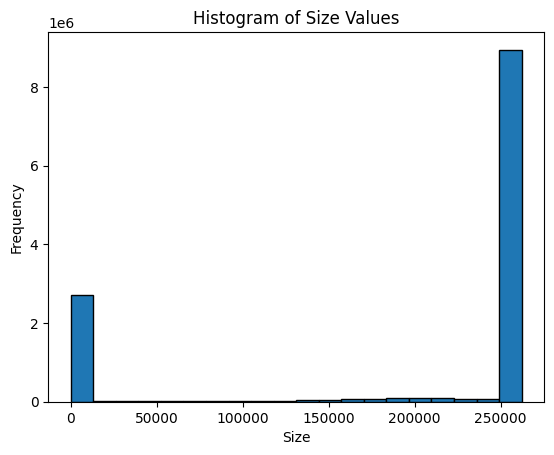

In [43]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and 'size' is the column you want to plot
plt.hist(analyze_df.compute()['size'], bins=20, edgecolor='black')  # Adjust bins as needed
plt.xlabel('Size')
plt.ylabel('Frequency')
plt.title('Histogram of Size Values')
plt.show()

In [9]:
analyzer.file_hash.head()

,name,pid,tid,hhash,mount_point
hash,,,,,
1.0003791731677315e+19,/collab/usr/gapps/python/build/spack-toss4.1/v...,1481567,1481567,14200274195875936004,/collab/usr/gapps
1.0051724955523748e+19,/usr/WS2/haridev/iopp/venvs/dlio_venv/lib/pyth...,1481567,1481567,14200274195875936004,/usr/WS2
1.0070743794630304e+19,/collab/usr/gapps/python/build/spack-toss4.1/v...,1481567,1481567,14200274195875936004,/collab/usr/gapps
1.0071480435238796e+18,/usr/WS2/haridev/iopp/venvs/dlio_venv/lib/pyth...,1481567,1481567,14200274195875936004,/usr/WS2
1.0091750875713778e+19,/collab/usr/gapps/python/build/spack-toss4.1/v...,1481567,1481567,14200274195875936004,/collab/usr/gapps


In [19]:
analyzer.file_hash.loc["1.0003791731677315e+19", 'mount_point'].compute()

hash
1.0003791731677315e+19    /collab/usr/gapps
Name: mount_point, dtype: string

In [18]:
analyzer.events['mount_point'] = analyzer.file_hash.loc[analyzer.events.fhash, 'mount_point']

KeyError: 'Cannot index with non-boolean dask Series. Try passing computed values instead (e.g. ``ddf.loc[iindexer.compute()]``)'

In [33]:
result = dd.merge(analyzer.events, analyzer.file_hash[['mount_point']], left_on='fhash', right_index = True, how='left')

In [18]:
analyzer_montage.string_hash.head()

,name
hash,
14683.0,DEFAULT
14683.0,DEFAULT
14683.0,DEFAULT
14683.0,DEFAULT
14683.0,DEFAULT


In [ ]:
a = analyzer_montage.file_hash.reset_index().compute()

In [ ]:

# eventsDF = analyzer_montage.events[analyzer_montage.events['cat'] == "POSIX" ] # only posix events
# all_mounts = analyzer.file_hash['mount_point'].unique().compute()
# all_mounts[all_mounts.str.startswith('/')]

In [ ]:
IFCalculator = DFGrepInterference(analyzer_montage.events, app_name=app_name, cp_dir=cp_dir, existing=False)

In [ ]:
IFCalculator.get_degree()
IFCalculator.get_interference()

In [ ]:
IFCalculator.write_checkpoint("inter", cp_dir=cp_dir)